# SVAR — Blanchard-Quah Identification

## Methodological framework

We estimate a bivariate SVAR following Blanchard & Quah (1989) for both Ukraine and the Euro Area.
The model contains two variables: **output growth** and **inflation**.

**Identification restriction:** demand shocks have no long-run effect on output (transitory), supply shocks do (permanent). This allows us to decompose Ukraine's inflation into:
- Supply shocks → remain Ukraine's own under EA membership (geopolitics, energy, agriculture)
- Demand shocks → would have been replaced by ECB policy under EA membership

**Counterfactual:** reconstruct Ukraine's inflation using its own supply shocks + EA demand shocks.

$$\hat{\pi}^{CF}_{UKR,t} = \text{IRF}_{supply} \times \varepsilon^{supply}_{UKR,t} + \text{IRF}_{demand} \times \varepsilon^{demand}_{EA,t}$$

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import linalg
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

cwd           = Path.cwd()
DATA_PROC     = cwd.parent / "data" / "data_processed"
DATA_EXT      = cwd.parent / "data" / "data_external"
OUTPUTS       = cwd.parent.parent / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Paths OK")

Paths OK


## 1. Data loading and preparation

In [13]:
# ── Inflation panel (from Analysis_part)
infl = pd.read_csv(DATA_PROC / "inflation_panel.csv",
                   parse_dates=["date"], index_col="date")

EA_COUNTRIES = [c for c in infl.columns if c != "UKR"]
ea_infl = infl[EA_COUNTRIES].mean(axis=1).rename("ea_infl")
ukr_infl = infl["UKR"].rename("ukr_infl")

# ── External data
ext = pd.read_csv(DATA_EXT / "external_data.csv",
                  parse_dates=["date"], index_col="date")

ukr_ip = ext["ukr_ip"].rename("ukr_ip")
ea_ip  = ext["ea_ip"].rename("ea_ip")

# ── Align all series on common sample
df = pd.DataFrame({
    "ukr_infl": ukr_infl,
    "ea_infl":  ea_infl,
    "ukr_ip":   ukr_ip,
    "ea_ip":    ea_ip,
}).dropna()

print(f"Common sample: {df.index.min().date()} → {df.index.max().date()}")
print(f"Observations: {len(df)}")
print()
print(df.describe().round(2))

Common sample: 2006-01-01 → 2023-10-01
Observations: 214

       ukr_infl  ea_infl  ukr_ip   ea_ip
count    214.00   214.00  214.00  214.00
mean      12.47     2.07   -3.83    0.56
std       11.60     2.18    9.64    6.62
min       -1.20    -0.67  -41.00  -28.46
25%        6.33     0.61   -9.73   -1.57
50%       10.64     1.65   -0.79    1.27
75%       14.78     2.60    2.55    3.55
max       60.91    10.73    8.41   41.11


## 2. Stationarity and transformation

Blanchard-Quah requires **stationary** series in the VAR.
For output growth (already a growth rate) this is typically satisfied.
For inflation we check — if non-stationary we take first differences.

In [23]:
# SVAR trivarié en niveaux : Brent + IP Ukraine + Inflation Ukraine
brent = ext["brent"].rename("brent")

ukr_var_data = pd.DataFrame({
    "brent":    brent,
    "ukr_ip":   ukr_ip,
    "ukr_infl": ukr_infl,
}).dropna()

ea_var_data = pd.DataFrame({
    "brent":   brent,
    "ea_ip":   ea_ip,
    "ea_infl": ea_infl,
}).dropna()

print(f"Ukraine VAR sample: {len(ukr_var_data)} obs | {ukr_var_data.index.min().date()} → {ukr_var_data.index.max().date()}")
print(f"EA VAR sample: {len(ea_var_data)} obs")
print()
print(ukr_var_data.describe().round(2))

Ukraine VAR sample: 240 obs | 2006-01-01 → 2025-12-01
EA VAR sample: 214 obs

        brent  ukr_ip  ukr_infl
count  240.00  240.00    240.00
mean    76.84   -2.97     11.75
std     23.63    9.43     11.19
min     18.38  -41.00     -1.20
25%     61.16   -8.40      5.76
50%     74.09    0.77      9.73
75%     94.04    4.13     14.47
max    132.72    8.41     60.91


## 3. Lag selection

In [24]:
model_ukr = VAR(ukr_var_data)
lag_order_ukr = model_ukr.select_order(maxlags=12)
p_ukr = lag_order_ukr.aic
print(f"Ukraine — lag sélectionné (AIC): {p_ukr}")

model_ea = VAR(ea_var_data)
lag_order_ea = model_ea.select_order(maxlags=12)
p_ea = lag_order_ea.aic
print(f"EA — lag sélectionné (AIC): {p_ea}")

Ukraine — lag sélectionné (AIC): 11
EA — lag sélectionné (AIC): 11


## 4. VAR estimation

In [25]:
p_ukr = min(p_ukr, 6)
p_ea  = min(p_ea,  6)

res_ukr = VAR(ukr_var_data).fit(p_ukr)
res_ea  = VAR(ea_var_data).fit(p_ea)

print(f"Ukraine VAR({p_ukr}) — AIC: {res_ukr.aic:.3f}")
print(f"EA VAR({p_ea}) — AIC: {res_ea.aic:.3f}")
print()
print("Ukraine sigma_u diag:", np.diag(res_ukr.sigma_u).round(3))
print("EA sigma_u diag:", np.diag(res_ea.sigma_u).round(3))

Ukraine VAR(6) — AIC: 3.992
EA VAR(6) — AIC: 3.774

Ukraine sigma_u diag: [36.659  0.409  2.893]
EA sigma_u diag: [43.199 10.836  0.094]


## 5. Blanchard-Quah structural identification

The BQ restriction: demand shocks have zero long-run effect on output.

We compute the long-run impact matrix $C(1) = (I - A_1 - ... - A_p)^{-1} B$
and impose a lower-triangular Cholesky decomposition on $C(1) \Sigma C(1)'$
to recover the structural shocks.

Variable ordering: **[output growth, inflation]**
→ supply shock affects both output and inflation in the long run
→ demand shock affects only inflation in the long run (zero restriction on output)

In [26]:
def blanchard_quah(var_result, var_data, p):
    k = var_result.neqs
    
    A = np.zeros((k, k))
    for i in range(p):
        A += var_result.coefs[i]
    
    C1    = np.linalg.inv(np.eye(k) - A)
    Sigma = var_result.sigma_u
    M     = C1 @ Sigma @ C1.T
    P     = np.linalg.cholesky(M)
    B0    = np.linalg.inv(C1) @ P

    resid        = np.array(var_result.resid)
    B0_inv       = np.linalg.inv(B0)
    struct_shocks = resid @ B0_inv.T

    idx = var_data.index[p:]
    return pd.DataFrame(
        struct_shocks,
        index=idx,
        columns=["oil_shock", "supply_shock", "demand_shock"]
    ), B0, C1


shocks_ukr, B0_ukr, C1_ukr = blanchard_quah(res_ukr, ukr_var_data, p_ukr)
shocks_ea,  B0_ea,  C1_ea  = blanchard_quah(res_ea,  ea_var_data,  p_ea)

print("Ukraine shocks:")
print(shocks_ukr.describe().round(3))
print("\nEA shocks:")
print(shocks_ea.describe().round(3))
print("\nUkraine shock correlations:")
print(shocks_ukr.corr().round(3))

Ukraine shocks:
       oil_shock  supply_shock  demand_shock
count    234.000       234.000       234.000
mean       0.000        -0.000         0.000
std        0.961         0.961         0.961
min       -3.478        -3.986        -4.331
25%       -0.650        -0.431        -0.387
50%        0.035         0.110        -0.001
75%        0.636         0.421         0.442
max        2.676         5.948         5.427

EA shocks:
       oil_shock  supply_shock  demand_shock
count    208.000       208.000       208.000
mean       0.000        -0.000        -0.000
std        0.956         0.956         0.956
min       -3.638        -4.395        -2.792
25%       -0.561        -0.389        -0.532
50%        0.071         0.006         0.039
75%        0.653         0.374         0.523
max        2.418         7.442         2.942

Ukraine shock correlations:
              oil_shock  supply_shock  demand_shock
oil_shock           1.0          -0.0           0.0
supply_shock       -0.0      

## 6. Impulse Response Functions

We plot the IRFs to validate the identification:
- Supply shock → permanent effect on output, effect on inflation
- Demand shock → transitory effect on output (should return to zero), effect on inflation

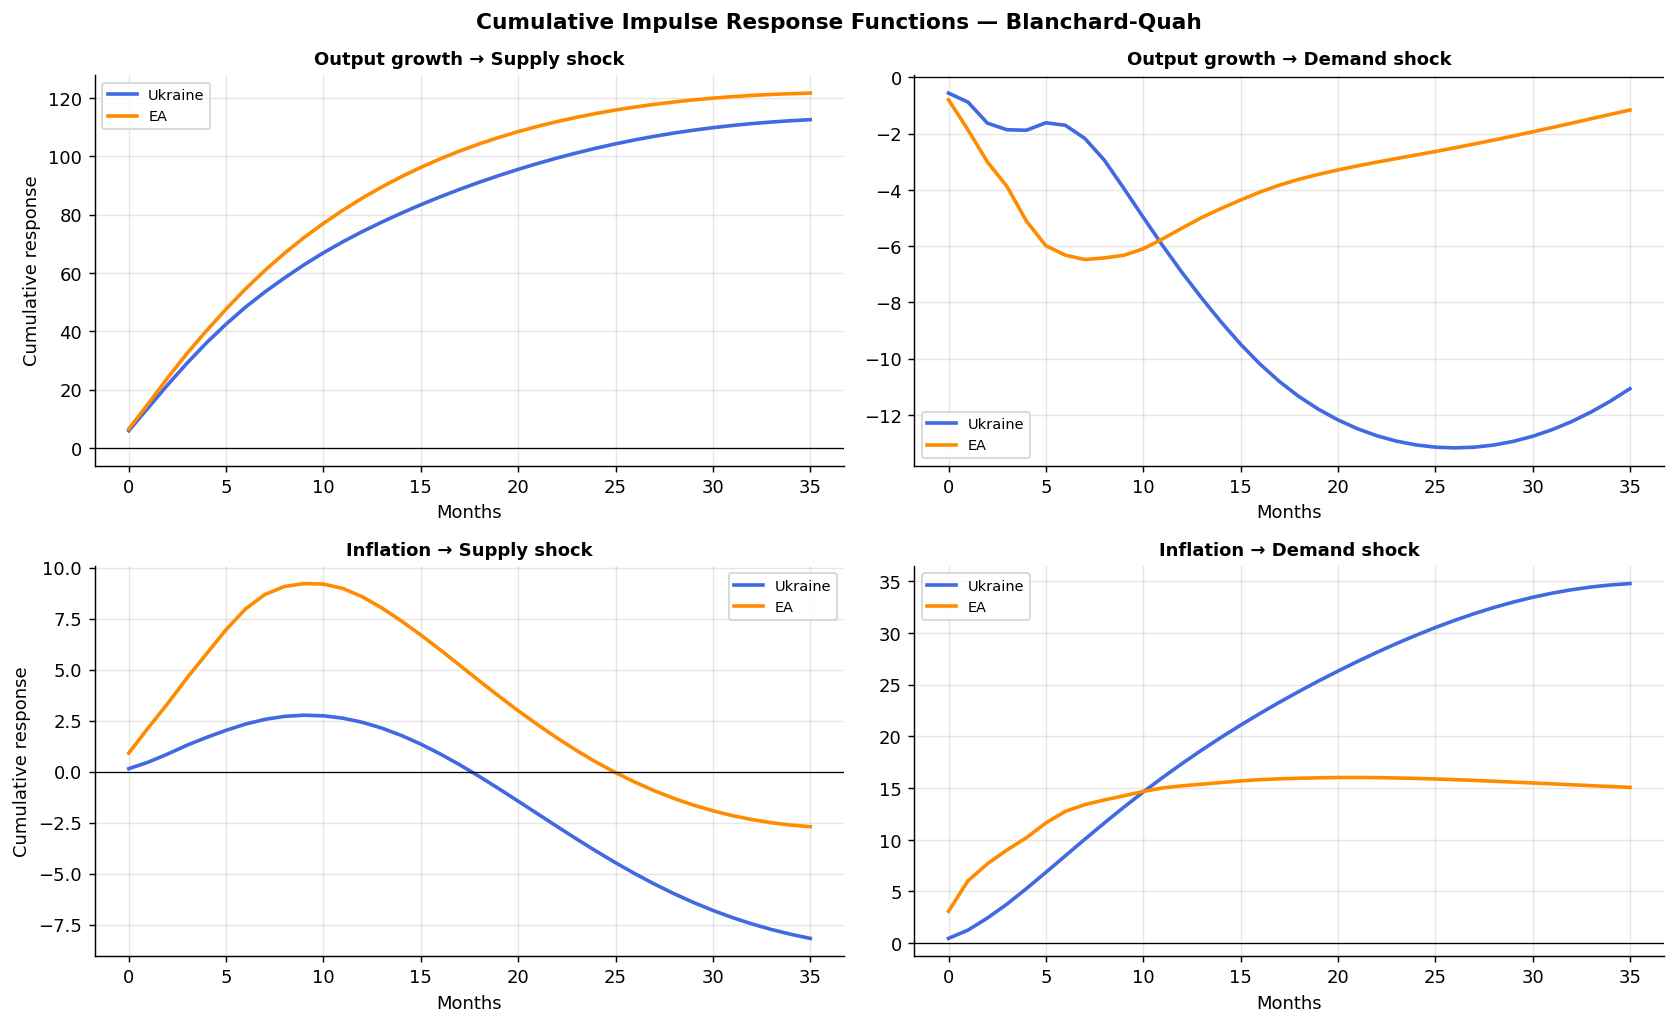

Long-run effect of demand shock on UA output: -11.0678 (should be ~0)
Long-run effect of demand shock on EA output: -1.1605 (should be ~0)


In [28]:
def compute_irf(B0, var_result, horizon=24):
    """
    Compute structural IRFs up to given horizon.
    Returns array (horizon x k x k): irf[h, response, shock]
    """
    k = var_result.neqs
    p = var_result.k_ar

    # Companion matrix for reduced-form
    phi = np.zeros((horizon, k, k))
    phi[0] = np.eye(k)
    for h in range(1, horizon):
        for j in range(min(h, p)):
            phi[h] += phi[h-1-j] @ var_result.coefs[j]

    # Structural IRF = reduced-form IRF @ B0
    irf = np.zeros((horizon, k, k))
    for h in range(horizon):
        irf[h] = phi[h] @ B0

    return irf


irf_ukr = compute_irf(B0_ukr, res_ukr, horizon=36)
irf_ea  = compute_irf(B0_ea,  res_ea,  horizon=36)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
labels = ["Output growth", "Inflation"]
shocks = ["Supply shock", "Demand shock"]

for i, shock in enumerate(shocks):
    for j, resp in enumerate(labels):
        ax = axes[j, i]
        ax.plot(np.cumsum(irf_ukr[:, j, i]), color="royalblue", lw=2, label="Ukraine")
        ax.plot(np.cumsum(irf_ea[:,  j, i]), color="darkorange", lw=2, label="EA")
        ax.axhline(0, color="black", lw=0.7)
        ax.set_title(f"{resp} → {shock}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Months")
        if i == 0: ax.set_ylabel("Cumulative response")
        ax.legend(fontsize=8)

plt.suptitle("Cumulative Impulse Response Functions — Blanchard-Quah",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "fig5_irf_blanchard_quah.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation: long-run effect of demand shock on output should be ~0
print(f"Long-run effect of demand shock on UA output: {np.cumsum(irf_ukr[:, 0, 1])[-1]:.4f} (should be ~0)")
print(f"Long-run effect of demand shock on EA output: {np.cumsum(irf_ea[:,  0, 1])[-1]:.4f} (should be ~0)")

## 7. Structural counterfactual

Under EA membership, Ukraine's **demand shocks** would have been replaced by EA demand shocks (ECB monetary policy). Its **supply shocks** remain its own (geopolitics, energy, agriculture are idiosyncratic).

The counterfactual inflation is reconstructed by:
1. Taking Ukraine's supply shocks
2. Replacing Ukraine's demand shocks with EA demand shocks (rescaled to Ukraine's shock variance)
3. Propagating through Ukraine's estimated inflation IRF

We also apply **treatment intensity weights** from Part A:
- Peg periods (2006-2008, 2010-2014): weight = 0.3 (Ukraine already had limited monetary sovereignty)
- Crisis/devaluation periods (2008-09, 2014-15, 2022): weight = 1.0 (full monetary sovereignty exercised)
- IT period (2016-2022): weight = 0.6 (partial monetary sovereignty)

In [40]:
common_idx = shocks_ukr.index.intersection(shocks_ea.index)

# Treatment intensity weights from Part A
weights = pd.Series(0.6, index=common_idx)
weights.loc["2006-01":"2008-03"] = 0.3
weights.loc["2010-01":"2014-01"] = 0.3
weights.loc["2008-04":"2009-12"] = 1.0
weights.loc["2014-02":"2015-12"] = 1.0
weights.loc["2022-02":"2023-09"] = 1.0

resid_actual = np.array(res_ukr.resid)
resid_cf     = resid_actual.copy()

scale = resid_actual[:, 2].std() / np.array(res_ea.resid)[:, 2].std()
n = min(len(resid_actual), len(res_ea.resid), len(common_idx))

weights_arr = weights.values[:n]
resid_cf[:n, 2] = (weights_arr * np.array(res_ea.resid)[:n, 2] * scale +
                   (1 - weights_arr) * resid_actual[:n, 2])

ukr_data_arr = np.array(ukr_var_data.loc[common_idx[0]:])
p = p_ukr
coefs = res_ukr.coefs
intercept = res_ukr.intercept

T = len(common_idx)
y_cf = np.zeros((T, 3))
y_cf[:p] = ukr_data_arr[:p]

for t in range(p, T):
    y_cf[t] = intercept.copy()
    for j in range(p):
        y_cf[t] += coefs[j] @ y_cf[t-1-j]
    y_cf[t] += resid_cf[t-p]

cf_scaled = pd.Series(y_cf[:, 2], index=common_idx, name="counterfactual_svar")
ukr_infl_common = ukr_infl.reindex(common_idx)
ea_infl_common  = ea_infl.reindex(common_idx)
gap = ukr_infl_common - cf_scaled

print("Counterfactual:")
print(cf_scaled.describe().round(2))
print(f"Gap: {gap.min():.1f}pp to {gap.max():.1f}pp")


Counterfactual:
count    208.00
mean      13.04
std       10.91
min       -0.52
25%        4.28
50%       10.56
75%       18.31
max       56.62
Name: counterfactual_svar, dtype: float64
Gap: -43.4pp to 49.4pp


## 8. Final figure

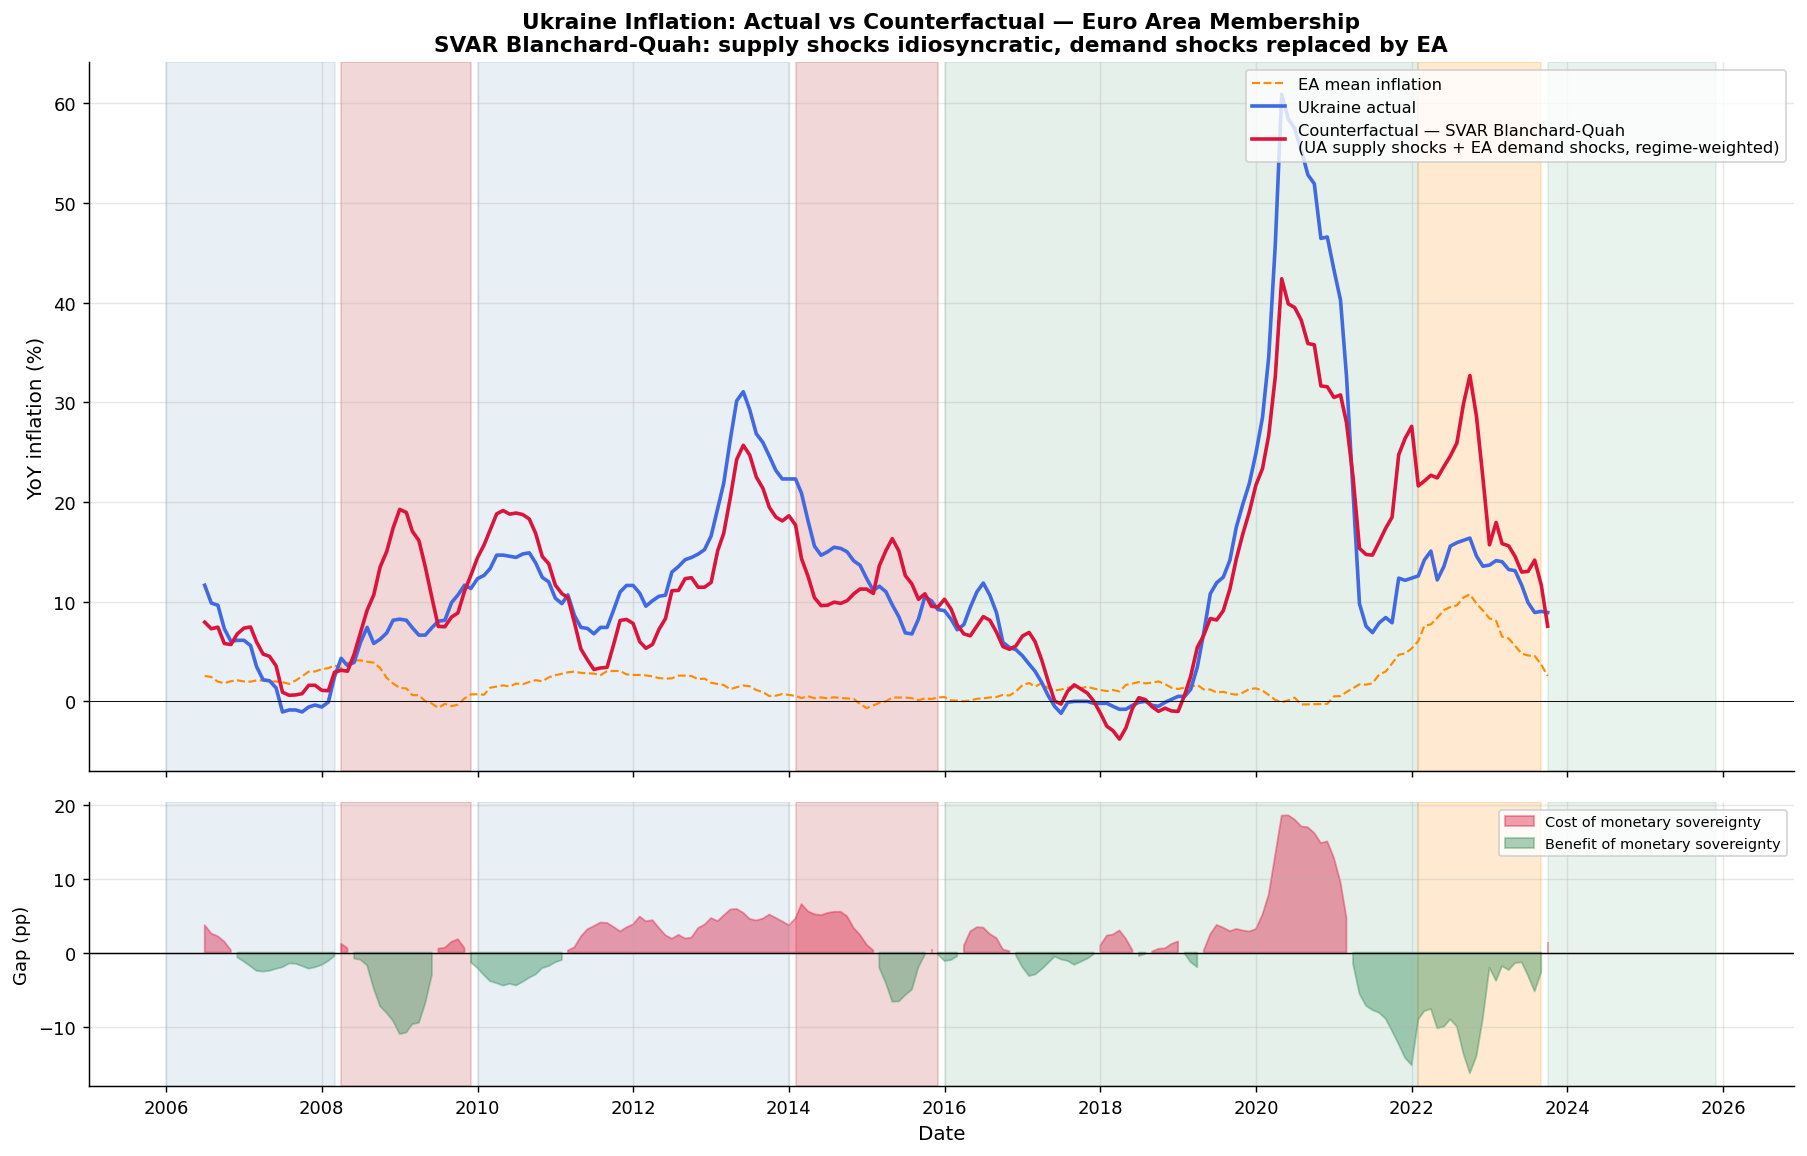

Figure saved.


In [42]:
REGIMES = [
    ("2006-01", "2008-03", "USD peg I",          "steelblue",  0.12),
    ("2008-04", "2009-12", "GFC devaluation",     "firebrick",  0.18),
    ("2010-01", "2014-01", "USD peg II",          "steelblue",  0.12),
    ("2014-02", "2015-12", "Crimea/Donbas",       "firebrick",  0.18),
    ("2016-01", "2022-02", "Inflation targeting", "seagreen",   0.12),
    ("2022-02", "2023-09", "Wartime peg",         "darkorange", 0.18),
    ("2023-10", "2025-12", "Managed float",       "seagreen",   0.10),
]

gap = ukr_infl_common - cf_scaled

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2.5, 1]})
ax, ax2 = axes

for start, end, _, color, alpha in REGIMES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=alpha)

ax.plot(ukr_infl_common.index, ea_infl_common, color="darkorange",
        lw=1.2, ls="--", label="EA mean inflation")
ax.plot(ukr_infl_common.index, ukr_infl_common, color="royalblue",
        lw=2, label="Ukraine actual")
ax.plot(cf_scaled.index, cf_scaled, color="crimson",
        lw=2, label="Counterfactual — SVAR Blanchard-Quah\n(UA supply shocks + EA demand shocks, regime-weighted)")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("YoY inflation (%)", fontsize=11)
ax.set_title(
    "Ukraine Inflation: Actual vs Counterfactual — Euro Area Membership\n"
    "SVAR Blanchard-Quah: supply shocks idiosyncratic, demand shocks replaced by EA",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper right")

ax2.fill_between(gap.index, gap, 0,
                 where=gap > 0, color="crimson", alpha=0.4,
                 label="Cost of monetary sovereignty")
ax2.fill_between(gap.index, gap, 0,
                 where=gap < 0, color="seagreen", alpha=0.4,
                 label="Benefit of monetary sovereignty")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Gap (pp)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=8, loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(OUTPUTS / "fig6_counterfactual_svar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 9. Period-by-period summary

In [21]:
episodes = [
    ("2006-01", "2008-03", "USD peg I"),
    ("2008-04", "2009-12", "GFC 2008-09"),
    ("2010-01", "2014-01", "USD peg II"),
    ("2014-02", "2015-12", "Crimea/Donbas"),
    ("2016-01", "2022-02", "Inflation targeting"),
    ("2022-02", "2023-09", "Wartime"),
    ("2023-10", "2025-12", "Managed float"),
]

print(f"{'Period':<25} {'Actual':>8} {'CF (SVAR)':>10} {'Gap':>8} {'Treatment w.':>13}")
print("-" * 68)
for s, e, label in episodes:
    m = (gap.index >= s) & (gap.index <= e)
    if m.sum() > 0:
        a  = ukr_infl_common[m].mean()
        c  = cf_scaled[m].mean()
        g  = gap[m].mean()
        w  = weights.reindex(gap.index[m]).mean() if s in weights.index or e in weights.index else "-"
        print(f"{label:<25} {a:>7.1f}%  {c:>9.1f}%  {g:>+7.1f}pp  {w:>12.1f}")

Period                      Actual  CF (SVAR)      Gap  Treatment w.
--------------------------------------------------------------------
USD peg I                     2.8%       12.0%     -9.1pp           0.3
GFC 2008-09                   7.4%       13.3%     -5.9pp           1.0
USD peg II                   15.1%       12.3%     +2.8pp           0.3
Crimea/Donbas                12.9%       11.9%     +0.9pp           1.0
Inflation targeting          13.9%       12.4%     +1.5pp           0.6
Wartime                      13.4%       12.0%     +1.3pp           1.0
Managed float                 8.9%        9.5%     -0.5pp           0.6


In [22]:
# Save results for final interpretation
results = pd.DataFrame({
    "ukr_actual":        ukr_infl_common,
    "ea_mean":           ea_infl_common,
    "counterfactual_svar": cf_scaled,
    "gap_svar":          gap,
    "supply_shock_ukr":  s_ukr["supply_shock"],
    "demand_shock_ukr":  s_ukr["demand_shock"],
    "demand_shock_ea":   s_ea["demand_shock"].reindex(common_idx),
    "treatment_weight":  weights,
})

results.to_csv(DATA_PROC / "svar_counterfactual.csv")
print("Saved → data_processed/svar_counterfactual.csv")
print(f"Shape: {results.shape}")

Saved → data_processed/svar_counterfactual.csv
Shape: (207, 8)
